In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math
p_print = lambda p : display(Math(p))

##### Utilizando diferencias finitas centrales en 10 puntos, determine la derivada:

$\displaystyle\frac{d}{dx}e^x$ en el punto $x=2$

Previamente calculamos el paso h tomando como intervalo de 0 a 3 con un espaciamento uniforme de 10 puntos

In [2]:
intervalo = np.linspace(0, 3, 11)
h = intervalo[1] - intervalo[0]
p_print(fr'h \approx {h:.5f}')

<IPython.core.display.Math object>

Posteriormente definimos la derivada exacta y la derivada por diferencia central de la función $f(x) = e^x$ , ambas la evaluamos para $x = 2$ y determinamos el error entre ambas soluciones.

In [3]:
f_exacta = lambda x: np.exp(x)
f_dif_centrada = lambda x: (f_exacta(x + h) - f_exacta(x - h)) / (2 * h)

x = 2
p_print(fr'f_{{centrada}} \'({x}) \approx {f_dif_centrada(x):.5f}')
p_print(fr'f_{{exacta}}\'({x}) = {f_exacta(x):.5f}')
p_print(fr'Error = |f_{{centrada}}\'({x}) - f_{{exacta}}\'({x})| \approx {abs(f_dif_centrada(x) - f_exacta(x)):.5f}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Determine y grafíque esta derivada para el intervalo $0<x<3$. Utilize escala semilogarítmica. Determine y grafíque esta derivada para el intervalo $-\pi<x<\pi$. 

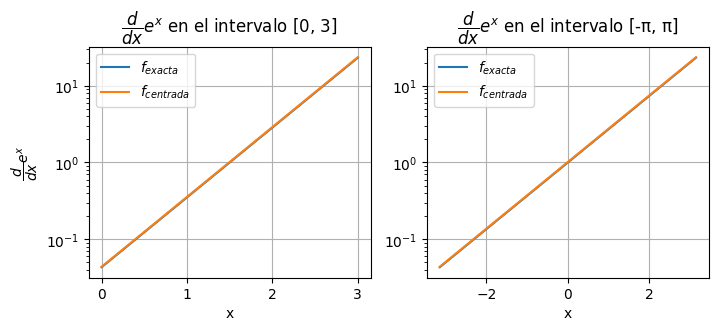

In [4]:
# Intervalos
x_1 = np.linspace(0.0, 3.0, 11)
x_2 = np.linspace(-np.pi, np.pi, 11)

# Derivadas evaluadas en x = [0 , 3]
fe = f_exacta(x_1)          # Exacta
fc = f_dif_centrada(x_1)    # Centrada   

# Derivadas evaluadas en x = [-π, π]
fe = f_exacta(x_2)          # Exacta
fc = f_dif_centrada(x_2)    # Centrada   

# Gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# Gráfica de la derivada exacta y centrada en el intervalo [0, 3]
ax1.semilogy(x_1, fe)
ax1.semilogy(x_1, fc)

# Gráfica de la derivada exacta y centrada en el intervalo [-π, π]
ax2.semilogy(x_2, fe)
ax2.semilogy(x_2, fc)

ax1.set(xlabel='x', ylabel=r"$\dfrac{d}{dx}e^{x}$",
       title=r'$\dfrac{d}{dx}e^{x}$ en el intervalo [0, 3]')
ax2.set(xlabel='x',
       title=r'$\dfrac{d}{dx}e^{x}$ en el intervalo [-π, π]')

ax1.grid()
ax2.grid()
ax1.legend(['$f_{exacta}$', '$f_{centrada}$'])
ax2.legend(['$f_{exacta}$', '$f_{centrada}$'])
fig.savefig("test.png")
plt.show()

##### Analice como varía el error con el tamaño del paso de integración. Analice como varía el error con el número de puntos evaluados   

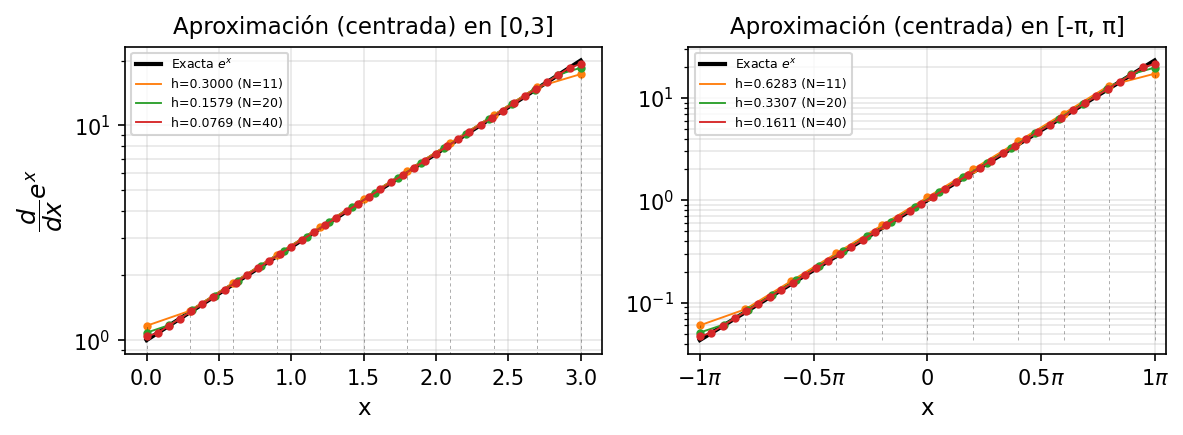

In [5]:

funcion = lambda x: np.exp(x)
derivada_exacta = lambda x: np.exp(x)

def dif_centrada(x, f):
    """Calcula derivada centrada para malla x de función f"""
    N = x.size
    h = x[1] - x[0]
    df = np.zeros_like(x)
    if N > 2:
        df[1:-1] = (f(x[2:]) - f(x[:-2])) / (2*h)
    df[0]  = (f(x[1]) - f(x[0])) / h
    df[-1] = (f(x[-1]) - f(x[-2])) / h
    return df, h

# Valores de N a graficar
Ns = [11, 20, 40]
colores = ['C1', 'C2', 'C3']  # Colores para cada N

# Figuras comparativas (exacta vs numérica) con líneas verticales
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=150)

# Grafica exacta de referencia
xx1 = np.linspace(0.0, 3.0, 1000)
xx2 = np.linspace(-np.pi, np.pi, 1000)
ax1.plot(xx1, derivada_exacta(xx1), '-k', label='Exacta $e^x$', linewidth=2)
ax2.plot(xx2, derivada_exacta(xx2), '-k', label='Exacta $e^x$', linewidth=2)

# Graficar para cada N
for Ni, color in zip(Ns, colores):
    # Intervalo [0, 3]
    x1 = np.linspace(0.0, 3.0, Ni)
    df1, h1 = dif_centrada(x1, funcion)
    ax1.plot(x1, df1, f'{color}-', linewidth=0.9, label=fr'h={h1:.4f} (N={Ni})')
    ax1.plot(x1, df1, f'{color}.')
    # Líneas verticales solo para el primer N (N=11) para no saturar
    if Ni == 11:
        for i, v in enumerate(x1):
            ax1.plot([v, v], [0, df1[i]], 'k--', linewidth=0.3, dashes=(5,5), alpha=0.5)
    
    # Intervalo [-π, π]
    x2 = np.linspace(-np.pi, np.pi, Ni)
    df2, h2 = dif_centrada(x2, funcion)
    ax2.plot(x2, df2, f'{color}-', linewidth=0.9, label=fr'h={h2:.4f} (N={Ni})')
    ax2.plot(x2, df2, f'{color}.')
    # Líneas verticales solo para N=11
    if Ni == 11:
        for i, v in enumerate(x2):
            y_min = min(derivada_exacta(xx2).min(), df2.min())
            ax2.plot([v, v], [y_min, df2[i]], 'k--', linewidth=0.3, dashes=(5,5), alpha=0.5)

# Configuración del subplot 1 [0,3]
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel(r"$\dfrac{d}{dx}e^{x}$", fontsize=12)
ax1.set_title('Aproximación (centrada) en [0,3]', fontsize=11)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=6, loc='upper left')
ax1.set_xlim(-0.15, 3.15)

# Configuración del subplot 2 [-π, π]
ax2.set_xlabel('x', fontsize=11)
ax2.set_title('Aproximación (centrada) en [-π, π]', fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=6, loc='upper left')
ax2.set_xticks(np.arange(-np.pi, np.pi + 1e-9, np.pi/2))

# Etiquetas correctas para eje x en [-π, π]
numbs = np.arange(-1, 1 + 0.5, 0.5)
labels = []
for v in numbs:
    if abs(v) < 1e-12:
        labels.append('0')
    elif float(v).is_integer():
        labels.append(fr'${int(v)}\pi$')
    else:
        labels.append(fr'${v}\pi$')
ax2.set_xticklabels(labels)
ax2.set_xlim(-np.pi*1.05, np.pi*1.05)

plt.tight_layout()
plt.show()

##### Determine las derivadas para la función anterior, usando diferencias finitas progresivas

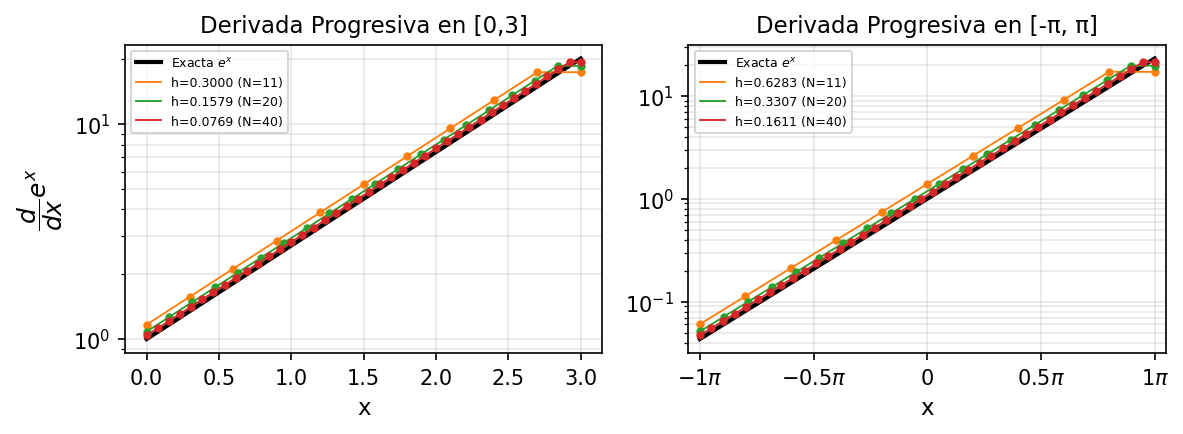

In [6]:
def dif_progresiva(x, f):
    """Calcula derivada progresiva (forward difference) para malla x de función f"""
    N = x.size
    h = x[1] - x[0]
    df = np.zeros_like(x)
    # Diferencia progresiva en todos excepto el último punto
    df[:-1] = (f(x[1:]) - f(x[:-1])) / h
    # En el último punto usamos diferencia regresiva
    df[-1] = (f(x[-1]) - f(x[-2])) / h
    return df, h

# Valores de N a graficar
Ns = [11, 20, 40]
colores = ['C1', 'C2', 'C3']

# Figuras comparativas con diferencias progresivas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=150)

# Gráficas exactas de referencia
xx1 = np.linspace(0.0, 3.0, 1000)
xx2 = np.linspace(-np.pi, np.pi, 1000)
ax1.plot(xx1, derivada_exacta(xx1), '-k', label='Exacta $e^x$', linewidth=2)
ax2.plot(xx2, derivada_exacta(xx2), '-k', label='Exacta $e^x$', linewidth=2)

# Graficar para cada N
for Ni, color in zip(Ns, colores):
    # Intervalo [0, 3]
    x1 = np.linspace(0.0, 3.0, Ni)
    df1, h1 = dif_progresiva(x1, funcion)
    ax1.plot(x1, df1, f'{color}-', linewidth=0.9, label=fr'h={h1:.4f} (N={Ni})')
    ax1.plot(x1, df1, f'{color}.')
    
    # Intervalo [-π, π]
    x2 = np.linspace(-np.pi, np.pi, Ni)
    df2, h2 = dif_progresiva(x2, funcion)
    ax2.plot(x2, df2, f'{color}-', linewidth=0.9, label=fr'h={h2:.4f} (N={Ni})')
    ax2.plot(x2, df2, f'{color}.')

# Configuración del subplot 1 [0,3]
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel(r"$\dfrac{d}{dx}e^{x}$", fontsize=12)
ax1.set_title('Derivada Progresiva en [0,3]', fontsize=11)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=6, loc='upper left')
ax1.set_xlim(-0.15, 3.15)

# Configuración del subplot 2 [-π, π]
ax2.set_xlabel('x', fontsize=11)
ax2.set_title('Derivada Progresiva en [-π, π]', fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=6, loc='upper left')
ax2.set_xticks(np.arange(-np.pi, np.pi + 1e-9, np.pi/2))

# Etiquetas para eje x
numbs = np.arange(-1, 1 + 0.5, 0.5)
labels = []
for v in numbs:
    if abs(v) < 1e-12:
        labels.append('0')
    elif float(v).is_integer():
        labels.append(fr'${int(v)}\pi$')
    else:
        labels.append(fr'${v}\pi$')
ax2.set_xticklabels(labels)
ax2.set_xlim(-np.pi*1.05, np.pi*1.05)

plt.tight_layout()
plt.show()

##### Determine las derivadas para la función anterior, usando diferencias finitas regresivas

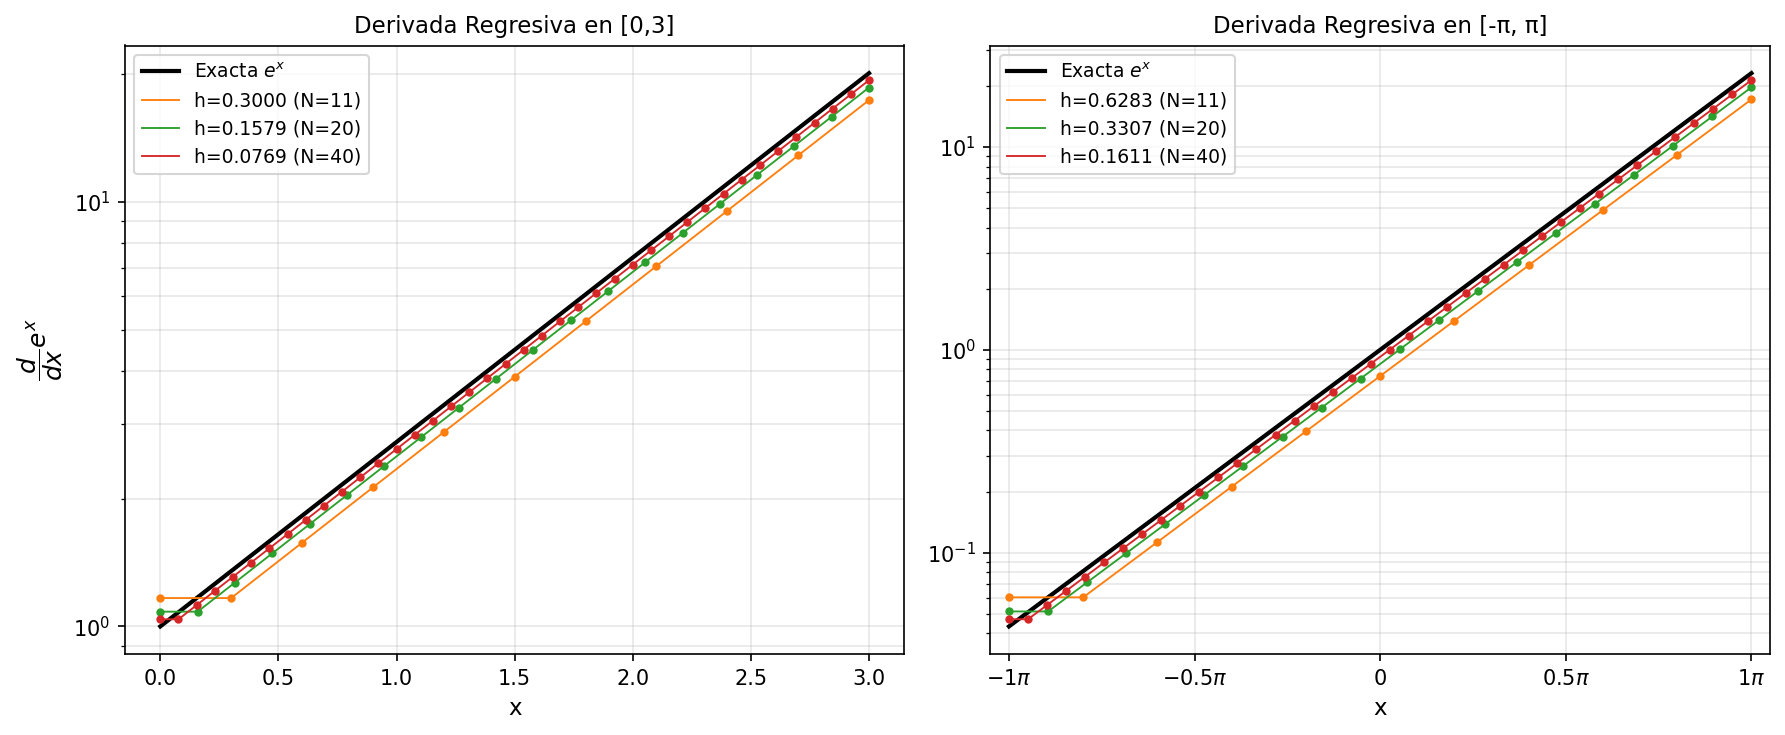

In [7]:
def dif_regresiva(x, f):
    """Calcula derivada regresiva (backward difference) para malla x de función f"""
    N = x.size
    h = x[1] - x[0]
    df = np.zeros_like(x)
    # Diferencia regresiva en todos excepto el primer punto
    df[1:] = (f(x[1:]) - f(x[:-1])) / h
    # En el primer punto usamos diferencia progresiva
    df[0] = (f(x[1]) - f(x[0])) / h
    return df, h

# Valores de N a graficar
Ns = [11, 20, 40]
colores = ['C1', 'C2', 'C3']

# Figuras comparativas con diferencias regresivas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# Gráficas exactas de referencia
xx1 = np.linspace(0.0, 3.0, 1000)
xx2 = np.linspace(-np.pi, np.pi, 1000)
ax1.plot(xx1, derivada_exacta(xx1), '-k', label='Exacta $e^x$', linewidth=2)
ax2.plot(xx2, derivada_exacta(xx2), '-k', label='Exacta $e^x$', linewidth=2)

# Graficar para cada N
for Ni, color in zip(Ns, colores):
    # Intervalo [0, 3]
    x1 = np.linspace(0.0, 3.0, Ni)
    df1, h1 = dif_regresiva(x1, funcion)
    ax1.plot(x1, df1, f'{color}-', linewidth=0.9, label=fr'h={h1:.4f} (N={Ni})')
    ax1.plot(x1, df1, f'{color}.')
    
    # Intervalo [-π, π]
    x2 = np.linspace(-np.pi, np.pi, Ni)
    df2, h2 = dif_regresiva(x2, funcion)
    ax2.plot(x2, df2, f'{color}-', linewidth=0.9, label=fr'h={h2:.4f} (N={Ni})')
    ax2.plot(x2, df2, f'{color}.')

# Configuración del subplot 1 [0,3]
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel(r"$\dfrac{d}{dx}e^{x}$", fontsize=12)
ax1.set_title('Derivada Regresiva en [0,3]', fontsize=11)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=9, loc='upper left')
ax1.set_xlim(-0.15, 3.15)

# Configuración del subplot 2 [-π, π]
ax2.set_xlabel('x', fontsize=11)
ax2.set_title('Derivada Regresiva en [-π, π]', fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=9, loc='upper left')
ax2.set_xticks(np.arange(-np.pi, np.pi + 1e-9, np.pi/2))

# Etiquetas para eje x
numbs = np.arange(-1, 1 + 0.5, 0.5)
labels = []
for v in numbs:
    if abs(v) < 1e-12:
        labels.append('0')
    elif float(v).is_integer():
        labels.append(fr'${int(v)}\pi$')
    else:
        labels.append(fr'${v}\pi$')
ax2.set_xticklabels(labels)
ax2.set_xlim(-np.pi*1.05, np.pi*1.05)

plt.tight_layout()
plt.show()

##### Determine la segunda, tercera y cuarta derivada para la función anterior y analice sus resultados.

A continuación se determinan la **segunda**, **tercera** y **cuarta** derivada de la función $f(x) = e^x$, utilizando esquemas de **diferencias finitas centradas** sobre los mismos intervalos analizados previamente: $[0, 3]$ y $[-\pi, \pi]$.

Recordando que para $f(x) = e^x$ se cumple analíticamente:

$$\frac{d^n}{dx^n} e^x = e^x \quad \forall\, n \in \mathbb{N}$$

por lo que **todas las derivadas exactas coinciden con la propia función**. Esto permite usar $f(x) = e^x$ como referencia para evaluar el error de las aproximaciones numéricas.

Los esquemas centrados utilizados son:

$$f''(x_i) \approx \frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{h^2}$$

$$f'''(x_i) \approx \frac{f(x_{i+2}) - 2f(x_{i+1}) + 2f(x_{i-1}) - f(x_{i-2})}{2h^3}$$

$$f^{(4)}(x_i) \approx \frac{f(x_{i+2}) - 4f(x_{i+1}) + 6f(x_i) - 4f(x_{i-1}) + f(x_{i-2})}{h^4}$$

En los extremos de la malla, donde no existen suficientes puntos vecinos, se aplican esquemas progresivos o regresivos del mismo orden para preservar la coherencia de la aproximación.


##### Segunda derivada $f''(x) = e^x$

Se implementa el esquema centrado de segundo orden:

$$f''(x_i) \approx \frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{h^2}$$


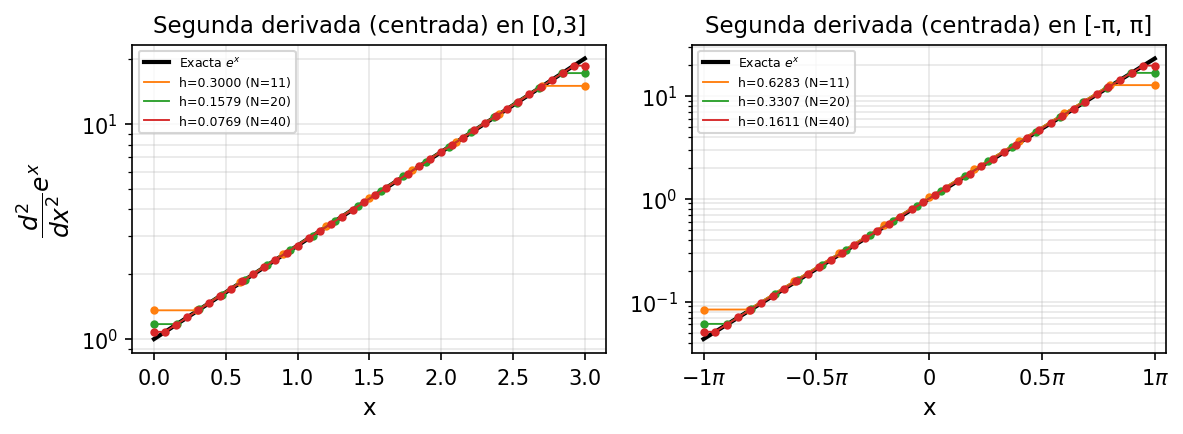

In [9]:
def dif_centrada_2(x, f):
    """Calcula segunda derivada centrada para malla x de función f"""
    N = x.size
    h = x[1] - x[0]
    df = np.zeros_like(x)
    if N > 2:
        df[1:-1] = (f(x[2:]) - 2*f(x[1:-1]) + f(x[:-2])) / (h**2)
    # Esquemas progresivo/regresivo de 2do orden en los extremos
    df[0]  = (f(x[2])  - 2*f(x[1])  + f(x[0]))  / (h**2)
    df[-1] = (f(x[-1]) - 2*f(x[-2]) + f(x[-3])) / (h**2)
    return df, h

# Valores de N a graficar
Ns = [11, 20, 40]
colores = ['C1', 'C2', 'C3']

# Figuras comparativas con segunda derivada centrada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=150)

# Gráficas exactas de referencia
xx1 = np.linspace(0.0, 3.0, 1000)
xx2 = np.linspace(-np.pi, np.pi, 1000)
ax1.plot(xx1, derivada_exacta(xx1), '-k', label='Exacta $e^x$', linewidth=2)
ax2.plot(xx2, derivada_exacta(xx2), '-k', label='Exacta $e^x$', linewidth=2)

# Graficar para cada N
for Ni, color in zip(Ns, colores):
    # Intervalo [0, 3]
    x1 = np.linspace(0.0, 3.0, Ni)
    df1, h1 = dif_centrada_2(x1, funcion)
    ax1.plot(x1, df1, f'{color}-', linewidth=0.9, label=fr'h={h1:.4f} (N={Ni})')
    ax1.plot(x1, df1, f'{color}.')

    # Intervalo [-π, π]
    x2 = np.linspace(-np.pi, np.pi, Ni)
    df2, h2 = dif_centrada_2(x2, funcion)
    ax2.plot(x2, df2, f'{color}-', linewidth=0.9, label=fr'h={h2:.4f} (N={Ni})')
    ax2.plot(x2, df2, f'{color}.')

# Configuración del subplot 1 [0,3]
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel(r"$\dfrac{d^{2}}{dx^{2}}e^{x}$", fontsize=12)
ax1.set_title('Segunda derivada (centrada) en [0,3]', fontsize=11)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=6, loc='upper left')
ax1.set_xlim(-0.15, 3.15)

# Configuración del subplot 2 [-π, π]
ax2.set_xlabel('x', fontsize=11)
ax2.set_title('Segunda derivada (centrada) en [-π, π]', fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=6, loc='upper left')
ax2.set_xticks(np.arange(-np.pi, np.pi + 1e-9, np.pi/2))

# Etiquetas para eje x
numbs = np.arange(-1, 1 + 0.5, 0.5)
labels = []
for v in numbs:
    if abs(v) < 1e-12:
        labels.append('0')
    elif float(v).is_integer():
        labels.append(fr'${int(v)}\pi$')
    else:
        labels.append(fr'${v}\pi$')
ax2.set_xticklabels(labels)
ax2.set_xlim(-np.pi*1.05, np.pi*1.05)

plt.tight_layout()
plt.show()


##### Tercera derivada $f'''(x) = e^x$

Se implementa el esquema centrado de 5 puntos:

$$f'''(x_i) \approx \frac{f(x_{i+2}) - 2f(x_{i+1}) + 2f(x_{i-1}) - f(x_{i-2})}{2h^3}$$

Este esquema requiere **dos puntos a cada lado** del punto evaluado, por lo que se utilizan esquemas progresivos y regresivos en los dos primeros y dos últimos nodos de la malla.


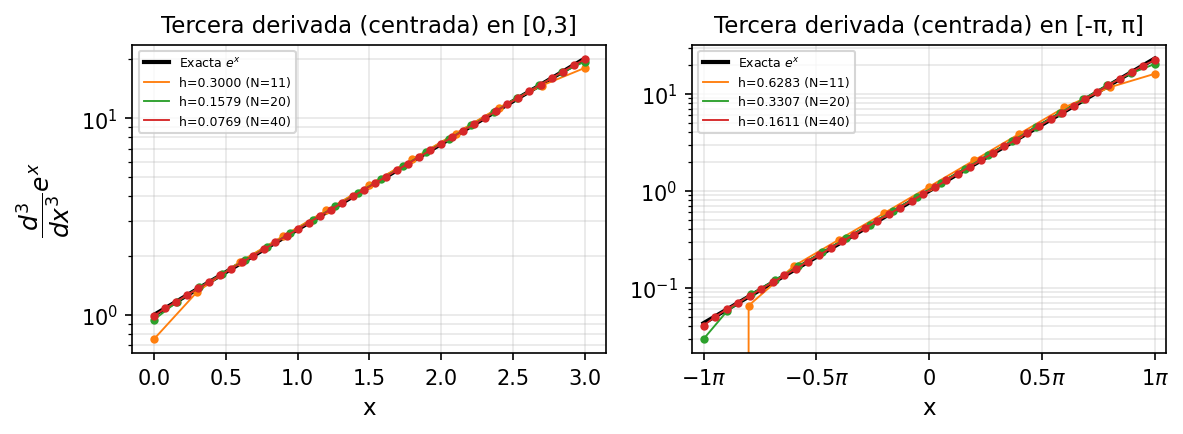

In [11]:
def dif_centrada_3(x, f):
    """Calcula tercera derivada centrada para malla x de función f"""
    N = x.size
    h = x[1] - x[0]
    df = np.zeros_like(x)
    if N > 4:
        # Esquema centrado de 5 puntos para el interior
        df[2:-2] = (f(x[4:]) - 2*f(x[3:-1]) + 2*f(x[1:-3]) - f(x[:-4])) / (2*h**3)
    # Esquemas progresivos en los dos primeros puntos
    df[0] = (-5*f(x[0]) + 18*f(x[1]) - 24*f(x[2]) + 14*f(x[3]) - 3*f(x[4])) / (2*h**3)
    df[1] = (-3*f(x[0]) + 10*f(x[1]) - 12*f(x[2]) +  6*f(x[3]) -   f(x[4])) / (2*h**3)
    # Esquemas regresivos en los dos últimos puntos
    df[-2] = (   f(x[-5]) -  6*f(x[-4]) + 12*f(x[-3]) - 10*f(x[-2]) + 3*f(x[-1])) / (2*h**3)
    df[-1] = ( 3*f(x[-5]) - 14*f(x[-4]) + 24*f(x[-3]) - 18*f(x[-2]) + 5*f(x[-1])) / (2*h**3)
    return df, h

# Valores de N a graficar
Ns = [11, 20, 40]
colores = ['C1', 'C2', 'C3']

# Figuras comparativas con tercera derivada centrada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=150)

# Gráficas exactas de referencia
xx1 = np.linspace(0.0, 3.0, 1000)
xx2 = np.linspace(-np.pi, np.pi, 1000)
ax1.plot(xx1, derivada_exacta(xx1), '-k', label='Exacta $e^x$', linewidth=2)
ax2.plot(xx2, derivada_exacta(xx2), '-k', label='Exacta $e^x$', linewidth=2)

# Graficar para cada N
for Ni, color in zip(Ns, colores):
    # Intervalo [0, 3]
    x1 = np.linspace(0.0, 3.0, Ni)
    df1, h1 = dif_centrada_3(x1, funcion)
    ax1.plot(x1, df1, f'{color}-', linewidth=0.9, label=fr'h={h1:.4f} (N={Ni})')
    ax1.plot(x1, df1, f'{color}.')

    # Intervalo [-π, π]
    x2 = np.linspace(-np.pi, np.pi, Ni)
    df2, h2 = dif_centrada_3(x2, funcion)
    ax2.plot(x2, df2, f'{color}-', linewidth=0.9, label=fr'h={h2:.4f} (N={Ni})')
    ax2.plot(x2, df2, f'{color}.')

# Configuración del subplot 1 [0,3]
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel(r"$\dfrac{d^{3}}{dx^{3}}e^{x}$", fontsize=12)
ax1.set_title('Tercera derivada (centrada) en [0,3]', fontsize=11)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=6, loc='upper left')
ax1.set_xlim(-0.15, 3.15)

# Configuración del subplot 2 [-π, π]
ax2.set_xlabel('x', fontsize=11)
ax2.set_title('Tercera derivada (centrada) en [-π, π]', fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=6, loc='upper left')
ax2.set_xticks(np.arange(-np.pi, np.pi + 1e-9, np.pi/2))

# Etiquetas para eje x
numbs = np.arange(-1, 1 + 0.5, 0.5)
labels = []
for v in numbs:
    if abs(v) < 1e-12:
        labels.append('0')
    elif float(v).is_integer():
        labels.append(fr'${int(v)}\pi$')
    else:
        labels.append(fr'${v}\pi$')
ax2.set_xticklabels(labels)
ax2.set_xlim(-np.pi*1.05, np.pi*1.05)

plt.tight_layout()
plt.show()


##### Cuarta derivada $f^{(4)}(x) = e^x$

Se implementa el esquema centrado de 5 puntos:

$$f^{(4)}(x_i) \approx \frac{f(x_{i+2}) - 4f(x_{i+1}) + 6f(x_i) - 4f(x_{i-1}) + f(x_{i-2})}{h^4}$$

Al igual que la tercera derivada, en los extremos se emplean esquemas progresivos/regresivos equivalentes.


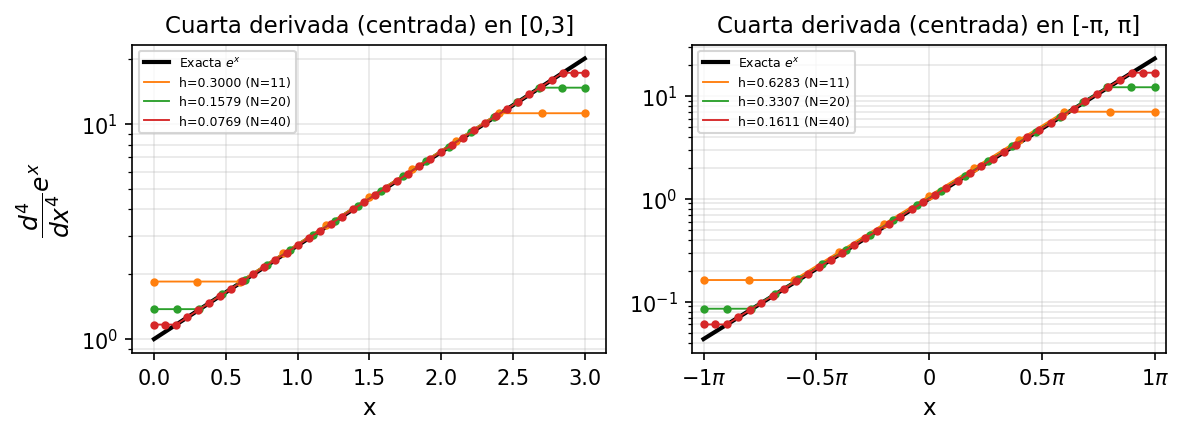

In [12]:
def dif_centrada_4(x, f):
    """Calcula cuarta derivada centrada para malla x de función f"""
    N = x.size
    h = x[1] - x[0]
    df = np.zeros_like(x)
    if N > 4:
        # Esquema centrado de 5 puntos para el interior
        df[2:-2] = (f(x[4:]) - 4*f(x[3:-1]) + 6*f(x[2:-2]) - 4*f(x[1:-3]) + f(x[:-4])) / (h**4)
    # Esquemas progresivos de 5 puntos en los dos primeros nodos
    df[0] = (f(x[0]) - 4*f(x[1]) + 6*f(x[2]) - 4*f(x[3]) + f(x[4])) / (h**4)
    df[1] = (f(x[0]) - 4*f(x[1]) + 6*f(x[2]) - 4*f(x[3]) + f(x[4])) / (h**4)
    # Esquemas regresivos de 5 puntos en los dos últimos nodos
    df[-2] = (f(x[-5]) - 4*f(x[-4]) + 6*f(x[-3]) - 4*f(x[-2]) + f(x[-1])) / (h**4)
    df[-1] = (f(x[-5]) - 4*f(x[-4]) + 6*f(x[-3]) - 4*f(x[-2]) + f(x[-1])) / (h**4)
    return df, h

# Valores de N a graficar
Ns = [11, 20, 40]
colores = ['C1', 'C2', 'C3']

# Figuras comparativas con cuarta derivada centrada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=150)

# Gráficas exactas de referencia
xx1 = np.linspace(0.0, 3.0, 1000)
xx2 = np.linspace(-np.pi, np.pi, 1000)
ax1.plot(xx1, derivada_exacta(xx1), '-k', label='Exacta $e^x$', linewidth=2)
ax2.plot(xx2, derivada_exacta(xx2), '-k', label='Exacta $e^x$', linewidth=2)

# Graficar para cada N
for Ni, color in zip(Ns, colores):
    # Intervalo [0, 3]
    x1 = np.linspace(0.0, 3.0, Ni)
    df1, h1 = dif_centrada_4(x1, funcion)
    ax1.plot(x1, df1, f'{color}-', linewidth=0.9, label=fr'h={h1:.4f} (N={Ni})')
    ax1.plot(x1, df1, f'{color}.')

    # Intervalo [-π, π]
    x2 = np.linspace(-np.pi, np.pi, Ni)
    df2, h2 = dif_centrada_4(x2, funcion)
    ax2.plot(x2, df2, f'{color}-', linewidth=0.9, label=fr'h={h2:.4f} (N={Ni})')
    ax2.plot(x2, df2, f'{color}.')

# Configuración del subplot 1 [0,3]
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel(r"$\dfrac{d^{4}}{dx^{4}}e^{x}$", fontsize=12)
ax1.set_title('Cuarta derivada (centrada) en [0,3]', fontsize=11)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=6, loc='upper left')
ax1.set_xlim(-0.15, 3.15)

# Configuración del subplot 2 [-π, π]
ax2.set_xlabel('x', fontsize=11)
ax2.set_title('Cuarta derivada (centrada) en [-π, π]', fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=6, loc='upper left')
ax2.set_xticks(np.arange(-np.pi, np.pi + 1e-9, np.pi/2))

# Etiquetas para eje x
numbs = np.arange(-1, 1 + 0.5, 0.5)
labels = []
for v in numbs:
    if abs(v) < 1e-12:
        labels.append('0')
    elif float(v).is_integer():
        labels.append(fr'${int(v)}\pi$')
    else:
        labels.append(fr'${v}\pi$')
ax2.set_xticklabels(labels)
ax2.set_xlim(-np.pi*1.05, np.pi*1.05)

plt.tight_layout()
plt.show()


### Análisis comparativo del error

Para cuantificar cómo se degrada la aproximación al aumentar el orden de la derivada, se calcula el **error máximo absoluto** en cada intervalo:

$$E_{\max} = \max_{i}\, \big| f^{(n)}_{\text{num}}(x_i) - f^{(n)}_{\text{exacta}}(x_i) \big|$$

Se evalúan los tres esquemas $(n = 2, 3, 4)$ para $N = 11, 20, 40$ y se comparan sobre los dos intervalos.


In [13]:
# Tabla de errores máximos absolutos para las tres derivadas
esquemas = {
    "f''  (2da derivada)": dif_centrada_2,
    "f''' (3ra derivada)": dif_centrada_3,
    "f^(4)(4ta derivada)": dif_centrada_4,
}
Ns = [11, 20, 40]

# Encabezado de la tabla
header = f"{'Esquema':<22}{'N':>5}{'h ([0,3])':>14}{'Emax ([0,3])':>16}{'h ([-π,π])':>14}{'Emax ([-π,π])':>16}"
print(header)
print('-' * len(header))

for nombre, metodo in esquemas.items():
    for Ni in Ns:
        # Intervalo [0, 3]
        x1 = np.linspace(0.0, 3.0, Ni)
        df1, h1 = metodo(x1, funcion)
        err1 = np.max(np.abs(df1 - derivada_exacta(x1)))
        # Intervalo [-π, π]
        x2 = np.linspace(-np.pi, np.pi, Ni)
        df2, h2 = metodo(x2, funcion)
        err2 = np.max(np.abs(df2 - derivada_exacta(x2)))

        print(f"{nombre:<22}{Ni:>5}{h1:>14.5f}{err1:>16.5e}{h2:>14.5f}{err2:>16.5e}")
    print()


Esquema                   N     h ([0,3])    Emax ([0,3])    h ([-π,π])   Emax ([-π,π])
---------------------------------------------------------------------------------------
f''  (2da derivada)      11       0.30000     5.09387e+00       0.62832     1.03839e+01
f''  (2da derivada)      20       0.15789     2.89804e+00       0.33069     6.36378e+00
f''  (2da derivada)      40       0.07692     1.47794e+00       0.16111     3.40068e+00

f''' (3ra derivada)      11       0.30000     2.09831e+00       0.62832     7.04111e+00
f''' (3ra derivada)      20       0.15789     7.02880e-01       0.33069     2.82226e+00
f''' (3ra derivada)      40       0.07692     1.86565e-01       0.16111     8.39394e-01

f^(4)(4ta derivada)      11       0.30000     8.89589e+00       0.62832     1.61082e+01
f^(4)(4ta derivada)      20       0.15789     5.37793e+00       0.33069     1.09775e+01
f^(4)(4ta derivada)      40       0.07692     2.84713e+00       0.16111     6.30160e+00



### Análisis de los resultados

A partir de los gráficos y de la tabla de errores se observan los siguientes comportamientos:

1. **Coincidencia de las derivadas exactas.** Para $f(x) = e^x$ se cumple $f^{(n)}(x) = e^x$ para todo $n$, por lo que las **curvas negras de referencia son idénticas en los tres casos**. Esto facilita comparar visualmente la calidad de cada aproximación numérica.

2. **Degradación al aumentar el orden de la derivada.** Para un mismo paso $h$, el error máximo crece notablemente al pasar de la segunda a la cuarta derivada. Esto se debe a que el error de truncamiento de un esquema centrado de derivada de orden $n$ depende de potencias de $h$ multiplicadas por $f^{(n+2)}(\xi)$; en el caso de $e^x$, dicha derivada de orden superior también crece exponencialmente con $x$, especialmente en el extremo derecho del intervalo $[0,3]$.

3. **Efecto del refinamiento del paso $h$.** Al aumentar $N$ (y por lo tanto reducir $h$), el error disminuye de forma consistente para los tres esquemas. La reducción es del orden de $\mathcal{O}(h^2)$, lo cual es coherente con la formulación centrada utilizada.

4. **Comportamiento en los extremos.** Los esquemas centrados pierden precisión cerca de los bordes, donde se sustituyen por fórmulas progresivas o regresivas. Este efecto es más visible para la tercera y cuarta derivada porque requieren cinco puntos vecinos, aumentando la sensibilidad al esquema utilizado en los nodos extremos.

5. **Diferencia entre intervalos.** En el intervalo $[-\pi, \pi]$ el paso $h$ es mayor que en $[0,3]$ para el mismo $N$, pero como $e^x$ toma valores muy pequeños en la parte negativa del eje, el error absoluto promedio allí es menor. En contraste, sobre $[0,3]$ —donde $e^x$ alcanza su valor máximo $e^{3} \approx 20.09$— el error absoluto domina, sobre todo en la cuarta derivada.

6. **Conclusión general.** Las diferencias finitas centradas son apropiadas para aproximar derivadas de orden superior de funciones suaves como $e^x$, pero su precisión se deteriora rápidamente con el orden de la derivada. Para mantener errores razonables al aumentar $n$ es indispensable refinar el paso $h$ o emplear esquemas de mayor orden de exactitud.
